# Chapter 22 — Bootstrap

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain the basic idea of bootstrap resampling
- Understand sampling **with replacement**
- Distinguish the original sample, bootstrap samples, and bootstrap statistics
- Approximate the sampling distribution of a statistic computationally
- Estimate bootstrap standard errors
- Construct percentile bootstrap confidence intervals
- Apply bootstrap methods to means, medians, and correlations
- Understand Monte Carlo variability in bootstrap results
- Recognize important limitations of the bootstrap


## 1. Why Bootstrap?

Earlier chapters introduced sampling distributions, standard errors, and confidence intervals.

Traditional statistical theory often gives us formulas such as

$$
SE(\bar{X}) = \frac{s}{\sqrt{n}}
$$

But what if:

- the statistic has no simple standard-error formula?
- the sampling distribution is difficult to derive?
- we want to estimate uncertainty for a median or another statistic?

The **bootstrap** offers a computational approach.

Instead of repeatedly collecting new real-world samples, we repeatedly resample the data we already observed.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "22_bootstrap.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,delivery_id,delivery_time_minutes,distance_km,orders_in_batch,satisfaction_score
0,D001,37.3,15.7,8,2
1,D002,41.8,11.2,7,2
2,D003,35.6,10.3,2,3
3,D004,34.4,11.5,6,4
4,D005,43.3,16.8,6,3


## 2. Dataset

We use a synthetic delivery-service dataset.

| Variable | Description |
|---|---|
| `delivery_id` | Fictional delivery identifier |
| `delivery_time_minutes` | Delivery time |
| `distance_km` | Delivery distance |
| `orders_in_batch` | Number of orders handled together |
| `satisfaction_score` | Customer satisfaction score, 1–5 |

Our main variable will be `delivery_time_minutes`.

All observations are fictional.


In [2]:
df.describe()


,delivery_time_minutes,distance_km,orders_in_batch,satisfaction_score
count,120.000000,120.000000,120.000000,120.000000
mean,35.147500,12.855833,4.583333,3.566667
std,8.123242,6.681755,2.478761,0.847471
min,22.100000,2.000000,1.000000,1.000000
25%,29.475000,7.075000,2.000000,3.000000
50%,34.450000,12.950000,5.000000,4.000000
75%,39.200000,18.850000,7.000000,4.000000
max,67.100000,24.500000,8.000000,5.000000


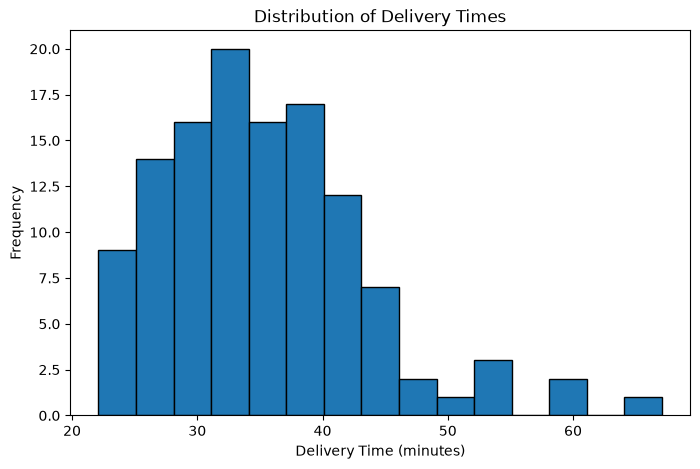

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(df["delivery_time_minutes"], bins=15, edgecolor="black")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Times")
plt.show()


## 3. The Core Bootstrap Idea

Suppose our original sample contains $n$ observations:

$$
x_1,x_2,\ldots,x_n
$$

A bootstrap sample is created by drawing **$n$ observations with replacement** from the original sample.

We then calculate the statistic of interest.

Repeat this process many times:

$$
\text{Original Sample}
\rightarrow
\text{Resample}
\rightarrow
\text{Statistic}
\rightarrow
\text{Repeat}
$$

The resulting collection of statistics is the **bootstrap distribution**.


## 4. What Does "With Replacement" Mean?

After an observation is selected, it is returned to the pool before the next draw.

Therefore, within one bootstrap sample:

- some original observations may appear more than once
- some original observations may not appear at all

The bootstrap sample normally has the **same size** as the original sample.


In [4]:
small_sample = np.array([10, 20, 30, 40, 50])
rng = np.random.default_rng(42)

bootstrap_example = rng.choice(
    small_sample,
    size=len(small_sample),
    replace=True,
)

print("Original sample :", small_sample)
print("Bootstrap sample:", bootstrap_example)


Original sample : [10 20 30 40 50]
Bootstrap sample: [10 40 40 30 30]


The repeated values are not an error.

They are a direct consequence of sampling with replacement.


## 5. Original Sample Statistic

Let's begin with the sample mean delivery time.


In [5]:
delivery_times = df["delivery_time_minutes"].to_numpy()

sample_mean = np.mean(delivery_times)
sample_median = np.median(delivery_times)

print("Sample mean:", sample_mean)
print("Sample median:", sample_median)


Sample mean: 35.14750000000001
Sample median: 34.45


The sample mean is one estimate calculated from one observed sample.

What we want to understand is:

> How much might this statistic vary across repeated samples?

The bootstrap approximates that uncertainty by treating the empirical distribution of the observed data as a stand-in for the unknown population distribution.


## 6. One Bootstrap Sample


In [6]:
rng = np.random.default_rng(42)

one_bootstrap_sample = rng.choice(
    delivery_times,
    size=len(delivery_times),
    replace=True,
)

print("Original mean :", np.mean(delivery_times))
print("Bootstrap mean:", np.mean(one_bootstrap_sample))


Original mean : 35.14750000000001
Bootstrap mean: 35.278333333333336


One bootstrap sample is not enough.

The power of the method comes from repeating the resampling process many times.


## 7. Generate Many Bootstrap Means

Let's create 10,000 bootstrap samples.

For each sample, calculate the mean.


In [7]:
rng = np.random.default_rng(42)
n_bootstrap = 10_000

bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    bootstrap_sample = rng.choice(
        delivery_times,
        size=len(delivery_times),
        replace=True,
    )
    bootstrap_means[i] = np.mean(bootstrap_sample)

bootstrap_means[:10]


array([35.27833333, 34.16666667, 35.16666667, 35.0375    , 34.16333333,
       35.57666667, 34.47166667, 36.7       , 34.91916667, 33.34083333])

## 8. Bootstrap Distribution

The 10,000 bootstrap means form an approximation to the sampling distribution of the sample mean.


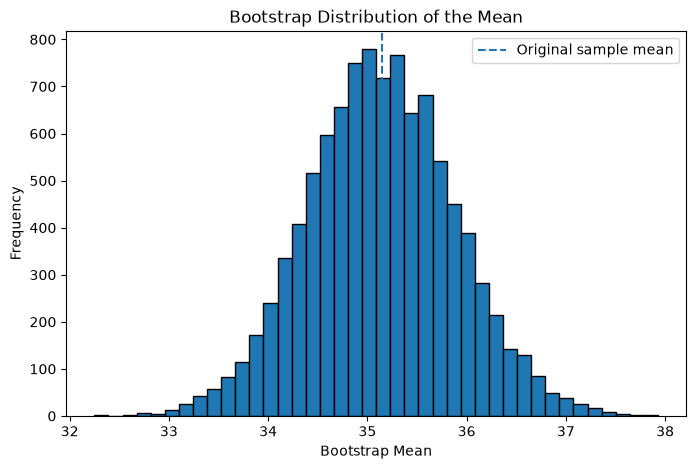

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=40, edgecolor="black")
plt.axvline(sample_mean, linestyle="--", label="Original sample mean")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Mean")
plt.legend()
plt.show()


In [9]:
pd.Series(bootstrap_means).describe()


count    10000.000000
mean        35.138231
std          0.744325
min         32.249167
25%         34.636667
50%         35.125833
75%         35.634167
max         37.928333
dtype: float64

Notice that the bootstrap distribution is a distribution of **statistics**, not a distribution of individual delivery times.

This distinction is important:

$$
\text{Original Data Distribution}
\neq
\text{Bootstrap Distribution of the Statistic}
$$


## 9. Bootstrap Standard Error

The standard deviation of the bootstrap statistics can be used as an estimate of the statistic's standard error.

$$
SE_{\text{boot}}
=
SD(\hat{\theta}^{*})
$$

where $\hat{\theta}^{*}$ represents a statistic calculated from a bootstrap sample.


In [10]:
bootstrap_se_mean = np.std(
    bootstrap_means,
    ddof=1,
)

print("Bootstrap SE of mean:", bootstrap_se_mean)


Bootstrap SE of mean: 0.744324778642505


## 10. Compare with the Analytical Standard Error

For the sample mean, we already know the familiar formula

$$
SE(\bar{X})
=
\frac{s}{\sqrt{n}}
$$

This gives us a useful check.


In [11]:
analytical_se_mean = (
    np.std(delivery_times, ddof=1)
    / np.sqrt(len(delivery_times))
)

print("Analytical SE:", analytical_se_mean)
print("Bootstrap SE :", bootstrap_se_mean)


Analytical SE: 0.7415471019036731
Bootstrap SE : 0.744324778642505


The two estimates should usually be reasonably close for this simple example.

But bootstrap becomes especially useful when a convenient analytical formula is unavailable or cumbersome.


## 11. Percentile Bootstrap Confidence Interval

A simple bootstrap confidence interval is the **percentile interval**.

For a nominal 95% interval, take the 2.5th and 97.5th percentiles of the bootstrap distribution:

$$
CI_{95\%}
=
\left[
Q_{0.025},
Q_{0.975}
\right]
$$


In [12]:
mean_ci = np.percentile(
    bootstrap_means,
    [2.5, 97.5],
)

print("95% percentile bootstrap CI for mean:")
print(mean_ci)


95% percentile bootstrap CI for mean:
[33.69414583 36.63252083]


This is intuitive:

- generate many plausible resampled statistics
- retain the middle 95% of their distribution

However, percentile intervals are only one bootstrap confidence-interval method. More advanced methods include **basic bootstrap** and **BCa intervals**.

This chapter focuses on the percentile method for conceptual clarity.


# Part B — Bootstrap the Median


## 12. Why Bootstrap a Median?

The median is often useful for skewed data and is less sensitive to extreme observations than the mean.

Its sampling uncertainty is not usually introduced with a simple formula as early as the standard error of the mean.

Bootstrap makes the procedure almost identical:

1. resample the observations
2. calculate the median
3. repeat


In [13]:
rng = np.random.default_rng(42)

bootstrap_medians = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    bootstrap_sample = rng.choice(
        delivery_times,
        size=len(delivery_times),
        replace=True,
    )
    bootstrap_medians[i] = np.median(bootstrap_sample)

bootstrap_medians[:10]


array([35.3 , 33.2 , 35.1 , 34.75, 33.35, 33.5 , 33.5 , 35.85, 32.6 ,
       32.8 ])

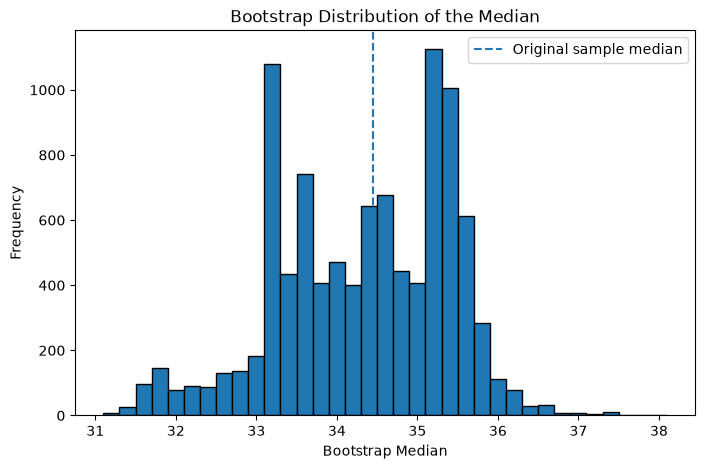

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_medians, bins=35, edgecolor="black")
plt.axvline(sample_median, linestyle="--", label="Original sample median")
plt.xlabel("Bootstrap Median")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Median")
plt.legend()
plt.show()


In [15]:
median_se = np.std(
    bootstrap_medians,
    ddof=1,
)

median_ci = np.percentile(
    bootstrap_medians,
    [2.5, 97.5],
)

print("Sample median:", sample_median)
print("Bootstrap SE:", median_se)
print("95% percentile bootstrap CI:", median_ci)


Sample median: 34.45
Bootstrap SE: 1.0694054977354743
95% percentile bootstrap CI: [31.8 35.9]


The same bootstrap algorithm can therefore be adapted to many different statistics simply by changing the calculation performed on each resample.


# Part C — Bootstrap a Correlation


## 13. Resampling Paired Rows

Suppose we want uncertainty for the correlation between delivery time and satisfaction.

There is an important detail:

> We must preserve the pairing between variables.

We should resample **rows**, not resample each column independently.

Otherwise, the relationship between each delivery time and its corresponding satisfaction score would be destroyed.


In [16]:
sample_correlation = df[
    ["delivery_time_minutes", "satisfaction_score"]
].corr().iloc[0, 1]

print("Sample correlation:", sample_correlation)


Sample correlation: -0.5256577273838111


In [17]:
rng = np.random.default_rng(42)
bootstrap_correlations = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    indices = rng.choice(
        len(df),
        size=len(df),
        replace=True,
    )

    boot = df.iloc[indices]

    bootstrap_correlations[i] = (
        boot[
            ["delivery_time_minutes", "satisfaction_score"]
        ]
        .corr()
        .iloc[0, 1]
    )

bootstrap_correlations[:10]


array([-0.48421607, -0.41061218, -0.54324427, -0.50766426, -0.44764932,
       -0.50892978, -0.49306638, -0.6089121 , -0.56049599, -0.48055784])

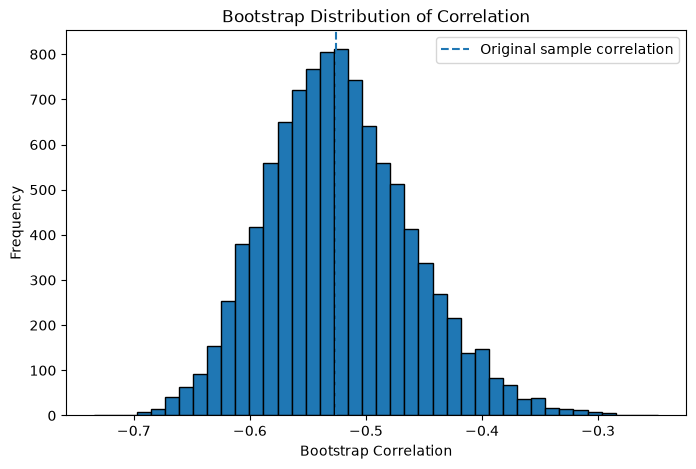

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_correlations, bins=40, edgecolor="black")
plt.axvline(
    sample_correlation,
    linestyle="--",
    label="Original sample correlation",
)
plt.xlabel("Bootstrap Correlation")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Correlation")
plt.legend()
plt.show()


In [19]:
correlation_ci = np.percentile(
    bootstrap_correlations,
    [2.5, 97.5],
)

print("Sample correlation:", sample_correlation)
print("95% percentile bootstrap CI:", correlation_ci)


Sample correlation: -0.5256577273838111
95% percentile bootstrap CI: [-0.63372094 -0.38900966]


This illustrates a broader rule:

- for a single variable, resample observations
- for relationships among variables measured on the same observational unit, resample the observational units together

The resampling scheme must respect the structure of the data.


## 14. Why Set a Random Seed?

Bootstrap is simulation-based.

Different random resamples can produce slightly different numerical results.

Using

```python
np.random.default_rng(42)
```

makes the educational example reproducible.

The seed does not make the bootstrap more statistically correct; it simply makes the random sequence reproducible.


## 15. Monte Carlo Variability

Even with the same original dataset, a finite number of bootstrap resamples introduces simulation variability.

Let's compare several values of $B$, the number of bootstrap replications.


In [20]:
def bootstrap_mean_ci(values, n_bootstrap, seed):
    rng = np.random.default_rng(seed)
    results = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )
        results[i] = np.mean(sample)

    return np.percentile(results, [2.5, 97.5])

for b in [100, 1_000, 10_000]:
    ci = bootstrap_mean_ci(
        delivery_times,
        n_bootstrap=b,
        seed=42,
    )
    print(f"B = {b:>5}: {ci}")


B =   100: [33.71204167 36.42104167]
B =  1000: [33.7073125  36.57933333]
B = 10000: [33.69414583 36.63252083]


With very few resamples, bootstrap summaries can be noticeably unstable.

Increasing $B$ reduces **Monte Carlo error** from the simulation itself.

It does not fix problems in the original sample.


## 16. What Bootstrap Can and Cannot Do

Bootstrap is powerful, but it is not magic.

### Bootstrap can help with

- approximating sampling distributions
- estimating standard errors
- constructing confidence intervals
- handling statistics with difficult analytical formulas

### Bootstrap cannot automatically fix

- biased or unrepresentative samples
- poor measurement
- dependence ignored by the resampling scheme
- extremely small samples with little information
- model or design problems
- causal-identification problems


## 17. The Original Sample Must Carry the Information

Bootstrap repeatedly resamples the **observed sample**.

Therefore, the method can only reproduce patterns that are represented in that sample.

If important parts of the population are missing from the original data, repeatedly resampling the same data does not restore the missing information.

A useful principle is:

> Bootstrap quantifies uncertainty from the available sample; it does not create new population information.


## 18. Independence and Data Structure

The simple bootstrap used in this chapter treats rows as independently resampleable observational units.

That may be inappropriate for data such as:

- time series
- clustered observations
- repeated measurements
- spatially dependent observations

Such data may require specialized resampling schemes, for example a block bootstrap or cluster bootstrap.

The resampling method should reflect the way the data were generated.


## 19. Bootstrap vs Permutation

Bootstrap and permutation methods both use repeated computation, but they answer different questions.

### Bootstrap

Typically samples **with replacement** to approximate uncertainty in a statistic.

### Permutation

Typically rearranges labels or values **without replacement** under a null hypothesis to create a reference distribution for a test.

In short:

$$
\text{Bootstrap}
\rightarrow
\text{Estimation / Uncertainty}
$$

$$
\text{Permutation}
\rightarrow
\text{Hypothesis Testing}
$$

This distinction will be useful when encountering resampling methods in practice.


## 20. A General Bootstrap Algorithm

For a statistic $\hat{\theta}$:

1. Observe a sample of size $n$.
2. Draw a bootstrap sample of size $n$ **with replacement**.
3. Calculate the statistic $\hat{\theta}^{*}$.
4. Repeat steps 2–3 a large number of times.
5. Use the distribution of $\hat{\theta}^{*}$ to estimate uncertainty.

Conceptually:

$$
\text{Observed Sample}
\rightarrow
\text{Bootstrap Samples}
\rightarrow
\text{Bootstrap Statistics}
\rightarrow
\text{Bootstrap Distribution}
\rightarrow
\text{SE / CI}
$$


## 21. Exercises

### Exercise 1
Explain in your own words why bootstrap sampling uses replacement.

### Exercise 2
Create one bootstrap sample from `delivery_time_minutes` and compare its mean with the original sample mean.

### Exercise 3
Generate 1,000 bootstrap means and visualize their distribution.

### Exercise 4
Increase the number of bootstrap replications to 10,000. Compare the confidence interval with the 1,000-replication result.

### Exercise 5
Calculate a bootstrap standard error for the mean and compare it with

$$
\frac{s}{\sqrt{n}}
$$

### Exercise 6
Construct a 95% percentile bootstrap confidence interval for the median.

### Exercise 7
Bootstrap the correlation between `delivery_time_minutes` and `satisfaction_score`.

Explain why rows must be resampled together.

### Exercise 8
Explain the difference between the distribution of raw observations and the bootstrap distribution of a statistic.

### Exercise 9
Explain why bootstrap cannot repair an unrepresentative original sample.

### Exercise 10
Explain the conceptual difference between bootstrap and permutation methods.


## 22. Summary

Bootstrap is a computational method for approximating sampling uncertainty.

The core procedure is simple:

$$
\text{Sample With Replacement}
\rightarrow
\text{Calculate Statistic}
\rightarrow
\text{Repeat Many Times}
$$

In this chapter, we used bootstrap to estimate uncertainty for:

- a mean
- a median
- a correlation

Key lessons:

- bootstrap samples usually have the same size as the original sample
- sampling is performed with replacement
- the bootstrap distribution is a distribution of statistics
- its standard deviation can estimate a standard error
- percentiles can be used to construct a simple confidence interval
- paired variables must be resampled together
- more replications reduce simulation error, not sampling bias
- bootstrap validity still depends on the quality and structure of the original data

### Next Chapter

**Chapter 23 — Comprehensive Statistical Analysis**

In the next chapter, we will bring together the statistical methods learned throughout this repository and apply them in a comprehensive end-to-end statistical analysis.

We will move from defining research questions and exploring data to hypothesis testing, relationship analysis, regression modeling, and statistical interpretation.
